In [1]:
import torch

In [2]:
from torchvision import datasets

In [3]:
download_dir = "./dataset"

# Скачиваем обучающую выборку.
train_data = datasets.CIFAR10(root=download_dir, download=True, train=True)

# Скачиваем валидационную выборку.
val_data = datasets.CIFAR10(root=download_dir, download=True, train=False)

In [4]:
# Объекты данных из обучающей выборки (50 000 цветных картинок размера 32 x 32).
x_train = torch.tensor(train_data.data)
x_train.shape

torch.Size([50000, 32, 32, 3])

In [5]:
# Предсказываемые величины для обучающей выборки (50 000 чисел от 0 до 9).
y_train = torch.tensor(train_data.targets)

print(y_train.shape, y_train.min(), y_train.max(), sep="\n")

torch.Size([50000])
tensor(0)
tensor(9)


In [6]:
# Сопоставление численных значений
#  (индексов в списке classes) реальным классам.
classes = train_data.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [7]:
# Названия классов на русском языке.
classes_ru = [
    "самолёт",
    "машина",
    "птица",
    "кошка",
    "олень",
    "собака",
    "лягушка",
    "лошадь",
    "корабль",
    "грузовик",
]

In [8]:
# Аналогично записываем x и y для валидационной выборки (10 000 примеров).
x_val = torch.tensor(val_data.data)
y_val = torch.tensor(val_data.targets)

print(x_val.shape, y_val.shape, sep="\n")

torch.Size([10000, 32, 32, 3])
torch.Size([10000])


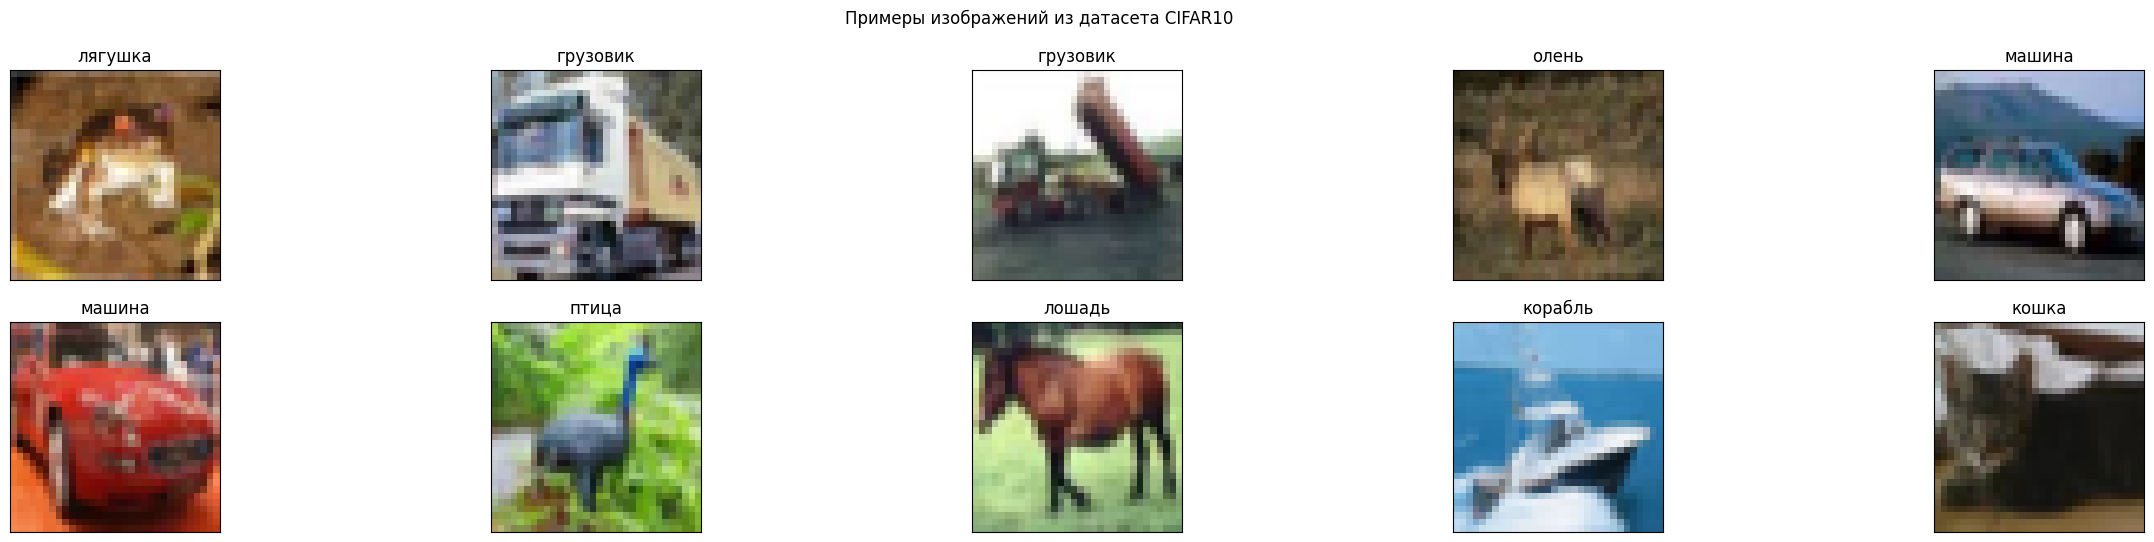

In [9]:
# Посмотрим на то, как выглядят картинки из датасета.

import matplotlib.pyplot as plt
%matplotlib inline

hh = 2
ww = 5

fig, ax = plt.subplots(hh, ww, figsize=(30, 3 * hh))
fig.suptitle("Примеры изображений из датасета CIFAR10")

for i, (x, y) in enumerate(zip(x_train, y_train)):
    if i >= hh * ww:
        break
    plt.subplot(hh, ww, i + 1)
    plt.imshow(x)
    plt.xticks([])
    plt.yticks([])
    plt.title(classes_ru[y])
plt.show()

In [10]:
# При обучении нейросетей нам будет удобнее работать
#  с пикселями, представленными в виде вещественных чисел.
x_train = torch.tensor(train_data.data) / 255.
x_val = torch.tensor(val_data.data) / 255.

print(x_train.min(), x_train.max(), x_train.dtype, sep="\n")

tensor(0.)
tensor(1.)
torch.float32


In [11]:
# Свёртка.
conv_layer = torch.nn.Conv2d(
    in_channels=3,         # Число каналов на входе.
    out_channels=10,       # Число каналов на выходе.
    kernel_size=3,         # Размер ядра.
    padding=1,             # Размер паддинга (1 элемент добавляется с каждой стороны).
    padding_mode="zeros",  # Указываем, что в паддинге проставляем нули вдоль границ входного тензора.
    stride=1,              # Stride - 1 (смотрим на каждую позицию).
    dilation=1,            # Dilation - 1 (ядро прикладывается к фрагменту изображения без пропусков).
)

# Применяется слой свёртки к группе картинок в формате bs x c x h x w.
x = torch.rand(2, 3, 32, 32)

print(f"Размер до свёртки: {x.shape}")

x = conv_layer(x)

print(f"Размер после свёртки: {x.shape}")

Размер до свёртки: torch.Size([2, 3, 32, 32])
Размер после свёртки: torch.Size([2, 10, 32, 32])


In [12]:
# Residual connection.
conv_layer_2 = torch.nn.Conv2d(
    in_channels=10,
    out_channels=10,
    kernel_size=3,
    padding=1,
)

x = torch.rand(2, 10, 32, 32)

print(f"Размер до свёртки: {x.shape}")

x2 = conv_layer_2(x)

print(f"Размер после свёртки: {x2.shape}")

h = x + x2

Размер до свёртки: torch.Size([2, 10, 32, 32])
Размер после свёртки: torch.Size([2, 10, 32, 32])


In [13]:
# Residual connection в ситуации, когда вход и выход
#  имеют разные количества каналов.
x = torch.rand(2, 3, 32, 32)

print(f"Размер до свёртки: {x.shape}")

x2 = conv_layer(x)

print(f"Размер после свёртки: {x2.shape}")

# Вариант 1: объединяем (конкатенируем) тензоры вдоль размерности каналов.
h = torch.cat([x, x2], dim=1)

print(f"Размер выхода при конкатенации: {h.shape}")


# Вариант 2: применяем свёртку с ядром 1x1, чтобы привести
#  исходный тензор к состоянию, когда число каналов
#  в нём совпадает с числом каналов в выходном тензоре.
conv_1_1 = torch.nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=1,  # Ищем шаблоны размера 1x1xc
)
h = conv_1_1(x) + x2

print(f"Размер выхода при сумме через 1x1 свёртку: {h.shape}")

Размер до свёртки: torch.Size([2, 3, 32, 32])
Размер после свёртки: torch.Size([2, 10, 32, 32])
Размер выхода при конкатенации: torch.Size([2, 13, 32, 32])
Размер выхода при сумме через 1x1 свёртку: torch.Size([2, 10, 32, 32])


In [14]:
# Напишем свой блок свёртки с residual connection.

class ResidualBlock(torch.nn.Module):
    # Инициализация блока.
    def __init__(
        self,
        input_c,                   # Число каналов на входе.
        output_c,                  # Число каналов на выходе.
        kernel_size,               # Размер ядра.
        activation=torch.nn.ReLU,  # Класс функции активации.
    ):
        super().__init__()

        # Функция активации для нелинейности.
        self.activation = activation()

        # TODO:
        # Паддинг подбираем такой, чтобы размеры h и w не менялись
        #  (считаем, что размер ядра всегда нечётный).
        padding_size = (kernel_size - 1) // 2

        # TODO:
        # Операция свёртки.
        # Создайте сверточный слой с помощью класса torch.nn.Conv2d
        # укажите количество каналов на входе и выходе, размер ядра,
        # размер паддинга и режим его выполнения (заполнение нулями)
        self.conv = torch.nn.Conv2d(
            in_channels= input_c,
            out_channels= output_c,
            kernel_size= kernel_size,
            padding= padding_size,
        )

        # Если числа каналов у входа и выхода различаются,
        if input_c != output_c:
            # ТОDO:
            # то будем делать свёртку с ядром размера 1.
            conv_1_1 = torch.nn.Conv2d(
                in_channels= input_c,
                out_channels= output_c,
                kernel_size= 1,  # Ищем шаблоны размера 1x1xc
            )
            self.correct_channels = conv_1_1

        else:
            self.correct_channels = torch.nn.Identity()  # Слой, никак не меняющий вход.

    # Прямой проход.
    def forward(self, x):
        # ТОDO:
        # реализуйте прямой проход
        # Применяем свертку
        out = self.conv(x)
        # Добавляем residual connection (с проекцией каналов при необходимости)
        out += self.correct_channels(x)
        # Применяем функцию активации
        return self.activation(out)

In [15]:
# TODO:
# Создайте экземпляр класса ResidualBlock() у которого 3 канала на входе, 10 каналов на выходе,
# размер ядра свертки равен 3 и
# в качестве функции активации используется ReLU

block = ResidualBlock(input_c=3, output_c=10, kernel_size=3)

In [16]:
# TODO:
# Создайте экземпляр класса ResidualBlock() у которого 10 каналов на входе, 10 каналов на выходе и
# размер ядра свертки равен 3 и
# в качестве функции активации используется "Гиперболический тангенс"

block = ResidualBlock(input_c=10, output_c=10, kernel_size=3, activation=torch.nn.Tanh)

In [17]:
# Соберём вручную простую свёрточную нейросеть,
#  используя написанный ранее residual block.
from collections import OrderedDict

conv_layers = [
    (
        "residual_block_1",
        # TODO:
        # Создайте экземпляр класса ResidualBlock() у которого 3 канала на входе, 8 каналов на выходе,
        # размер ядра свертки равен 3 и
        # в качестве функции активации используется ReLU
       
        ResidualBlock(input_c=3, output_c=8, kernel_size=3)
    ),
    (
        "residual_block_2",
        # TODO:
        # Создайте экземпляр класса ResidualBlock() у которого 8 каналов на входе, 16 каналов на выходе,
        # размер ядра свертки равен 3 и
        # в качестве функции активации используется ReLU
       
        ResidualBlock(input_c=8, output_c=16, kernel_size=3)
    ),
    (
        "pooling",
        torch.nn.MaxPool2d(kernel_size=2),
    ),
    (
        "residual_block_3",
        # TODO:
        # Создайте экземпляр класса ResidualBlock() у которого 16 каналов на входе, 32 канала на выходе,
        # размер ядра свертки равен 3 и
        # в качестве функции активации используется ReLU
       
        ResidualBlock(input_c=16, output_c=32, kernel_size=3)
    ),
]

conv_model = torch.nn.Sequential(OrderedDict(conv_layers))
conv_model

Sequential(
  (residual_block_1): ResidualBlock(
    (activation): ReLU()
    (conv): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (correct_channels): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
  )
  (residual_block_2): ResidualBlock(
    (activation): ReLU()
    (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (correct_channels): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
  )
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (residual_block_3): ResidualBlock(
    (activation): ReLU()
    (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (correct_channels): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [18]:
# С помощью функции max в torch можно сделать MaxPooling.
h = torch.rand(2, 3)

print(h, h.max(1), h.max(1).values.shape, h[0, :], h[1, :], sep="\n\n")

tensor([[0.7127, 0.4073, 0.7892],
        [0.7547, 0.1162, 0.3397]])

torch.return_types.max(
values=tensor([0.7892, 0.7547]),
indices=tensor([2, 0]))

torch.Size([2])

tensor([0.7127, 0.4073, 0.7892])

tensor([0.7547, 0.1162, 0.3397])


In [19]:
# Теперь соберём вручную классификатор.
lin_layers = [
    (
        "linear_1",
        # TODO:
        # Сделайте полносвязный слой у которого 32 канала на входе, 16 каналов на выходе,
        # создайте для этого экземпляр класса torch.nn.Linear
        torch.nn.Linear(in_features=32, out_features=16)
    ),
    (
        "linear_activation_1",
        # TODO:
        # в качестве функции активации используется ReLU
        torch.nn.ReLU()
    ),
    (
        "linear_2",
        # TODO:
        # Сделайте полносвязный слой у которого 16 каналов на входе, 10 каналов на выходе,
        # создайте для этого экземпляр класса torch.nn.Linear
        torch.nn.Linear(in_features=16, out_features=10)
    ),
    (
        "softmax",
        torch.nn.Softmax(-1),
    ),
]

lin_model = torch.nn.Sequential(OrderedDict(lin_layers))
lin_model

Sequential(
  (linear_1): Linear(in_features=32, out_features=16, bias=True)
  (linear_activation_1): ReLU()
  (linear_2): Linear(in_features=16, out_features=10, bias=True)
  (softmax): Softmax(dim=-1)
)

In [20]:
# Посмотрим на примере.
x = torch.rand(2, 3, 32, 32)

print(f"Изначальный размер: {x.shape}")

# Применяем свёрточные слои.
x = conv_model(x)

print(f"После свёрток: {x.shape}")

# Сделаем операцию GlobalMaxPooling.
x = x.max(-1).values.max(-1).values

print(f"После глобального пулинга: {x.shape}")

# Применяем классификатор.
x = lin_model(x)

print(f"После классификатора: {x.shape}\n")

print(x, x.sum(1), sep="\n\n")

Изначальный размер: torch.Size([2, 3, 32, 32])
После свёрток: torch.Size([2, 32, 16, 16])
После глобального пулинга: torch.Size([2, 32])
После классификатора: torch.Size([2, 10])

tensor([[0.0999, 0.1119, 0.1003, 0.0862, 0.1069, 0.0892, 0.1183, 0.0790, 0.0877,
         0.1206],
        [0.0994, 0.1118, 0.0997, 0.0871, 0.1067, 0.0893, 0.1175, 0.0786, 0.0885,
         0.1214]], grad_fn=<SoftmaxBackward0>)

tensor([1.0000, 1.0000], grad_fn=<SumBackward1>)


In [21]:

# Повторим задание свёрточной нейронной сети на основе residual block,
# но в более общем виде при помощи обёртки torch.nn.Module.
IMG_SIZE = 32

class ResidualModel(torch.nn.Module):
    def __init__(
        self,
        out_size,                    # Число классов.
        residual_sizes,              # Задаём список троек: количество residual-блоков,
                                     #  число каналов и размер ядра в каждом таком блоке.
        linear_sizes,                # Список размеров линейных слоёв в финальном классификаторе.
        activation = torch.nn.ReLU,  # Какую функцию активации использовать.
        flatten = True,              # Использовать Flatten или GlobalPooling.
    ):
        super().__init__()
        self.flatten = flatten

        # Собираем все свёрточные слои в один блок.
        conv_layers = []

        current_c = 3
        for group_index, (num_residual, out_channels, kernel_size) in enumerate(residual_sizes):
            for residual_index in range(num_residual):
                conv_layers.append((
                    # Добавляем несколько residual-блоков для каждой группы.
                    f"residual_{group_index}_{residual_index}",
                    ResidualBlock(
                        input_c = current_c if residual_index == 0 else out_channels,
                        output_c = out_channels,
                        kernel_size = kernel_size,
                        activation = activation,
                    ),
                ))
            current_c = out_channels
            if group_index < len(residual_sizes) - 1:
                conv_layers.append((
                    # В конце группы добавляем один pooling-слой,
                    # если это не последняя группа.
                    f"pooling_{group_index}",
                    torch.nn.AvgPool2d(2),
                ))

        self.conv_part = torch.nn.Sequential(OrderedDict(conv_layers))

        # Собираем все линейные слои во второй блок.
        out_c = residual_sizes[-1][1]
        final_size = IMG_SIZE // 2 ** (len(residual_sizes) - 1)
        clf_in_size = (out_c * final_size**2) if flatten else out_c

        linear_sizes = [clf_in_size, *linear_sizes, out_size]

        clf_layers = []

        for i, (from_size, to_size) in enumerate(zip(linear_sizes[:-1], linear_sizes[1:])):
            clf_layers.append((f"linear_{i}", torch.nn.Linear(from_size, to_size)))
            if i < len(linear_sizes) - 2:
                clf_layers.append((f"act_{i}", activation()))
            else:
                clf_layers.append(("log_softmax", torch.nn.LogSoftmax(-1)))

        self.clf_part = torch.nn.Sequential(OrderedDict(clf_layers))

    def forward(self, x):  # input (bs x h x w x c_in)
        x = x.permute((0, 3, 1, 2))  # (bs x c_in x h x w)

        x = self.conv_part(x)  # bs x c_out x h' x w'

        if self.flatten:
            # Операция Flatten.
            x = x.reshape(x.shape[0], -1)  # bs x (c_out * h' * w')
        else:
            # Операция GlobalMaxPooling.
            x = x.max(-1).values.max(-1).values  # bs x c_out


        x = self.clf_part(x)  # bs x 10

        return x




In [22]:
def print_num_params(model):
    # Считаем общее количество обучаемых весов в модели.
    sum_params_size = 0
    for name, param in model.named_parameters():
        param_size = param.numel()
        print("{:<46} ~ {:<14} ~ {}".format(name, str(list(param.shape)), param_size))
        sum_params_size += param_size
    print(f"Общее число параметров ~ {sum_params_size}")


In [23]:
model = ResidualModel(
    out_size=10,
    residual_sizes=[(2, 8, 3), (2, 16, 3), (2, 32, 3), (2, 32, 3)],
    linear_sizes=[32],
    activation=torch.nn.ReLU,
    flatten=True,
)

model

ResidualModel(
  (conv_part): Sequential(
    (residual_0_0): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
    )
    (residual_0_1): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Identity()
    )
    (pooling_0): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (residual_1_0): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
    )
    (residual_1_1): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Identity()
    )
    (pooling_1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (residual_2_0): Re

In [24]:
print_num_params(model)

conv_part.residual_0_0.conv.weight             ~ [8, 3, 3, 3]   ~ 216
conv_part.residual_0_0.conv.bias               ~ [8]            ~ 8
conv_part.residual_0_0.correct_channels.weight ~ [8, 3, 1, 1]   ~ 24
conv_part.residual_0_0.correct_channels.bias   ~ [8]            ~ 8
conv_part.residual_0_1.conv.weight             ~ [8, 8, 3, 3]   ~ 576
conv_part.residual_0_1.conv.bias               ~ [8]            ~ 8
conv_part.residual_1_0.conv.weight             ~ [16, 8, 3, 3]  ~ 1152
conv_part.residual_1_0.conv.bias               ~ [16]           ~ 16
conv_part.residual_1_0.correct_channels.weight ~ [16, 8, 1, 1]  ~ 128
conv_part.residual_1_0.correct_channels.bias   ~ [16]           ~ 16
conv_part.residual_1_1.conv.weight             ~ [16, 16, 3, 3] ~ 2304
conv_part.residual_1_1.conv.bias               ~ [16]           ~ 16
conv_part.residual_2_0.conv.weight             ~ [32, 16, 3, 3] ~ 4608
conv_part.residual_2_0.conv.bias               ~ [32]           ~ 32
conv_part.residual_2_0.corre

In [25]:
# TODO:
# Используя созданный ранее класс ResidualModel,
# создайте нейронную сеть с такой же архитектурой как и ранее,
# но использующую глобальный MaxPooling перед применением полносвязных слоев 
model = ResidualModel(
    out_size=10,
    residual_sizes=[(2, 8, 3), (2, 16, 3), (2, 32, 3), (2, 32, 3)],
    linear_sizes=[32],
    activation=torch.nn.ReLU,
    flatten=False,
)

model

ResidualModel(
  (conv_part): Sequential(
    (residual_0_0): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
    )
    (residual_0_1): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Identity()
    )
    (pooling_0): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (residual_1_0): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
    )
    (residual_1_1): ResidualBlock(
      (activation): ReLU()
      (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (correct_channels): Identity()
    )
    (pooling_1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (residual_2_0): Re

In [26]:
# TODO:
# выведите подробную информацию о коичечестве параметров этой неросети 

def print_model_parameters(model):
    total_params = 0
    for name, module in model.named_children():
        params = sum(p.numel() for p in module.parameters())
        total_params += params
        print(f"Слой: {name:20} | Параметры: {params:8,} | Тип: {str(type(module))[8:-2]}")
    print(f"\nВсего параметров: {total_params:,}")

# Выводим информацию о модели
print_model_parameters(model)


Слой: conv_part            | Параметры:   37,400 | Тип: torch.nn.modules.container.Sequential
Слой: clf_part             | Параметры:    1,386 | Тип: torch.nn.modules.container.Sequential

Всего параметров: 38,786


In [27]:
import matplotlib.pyplot as plt

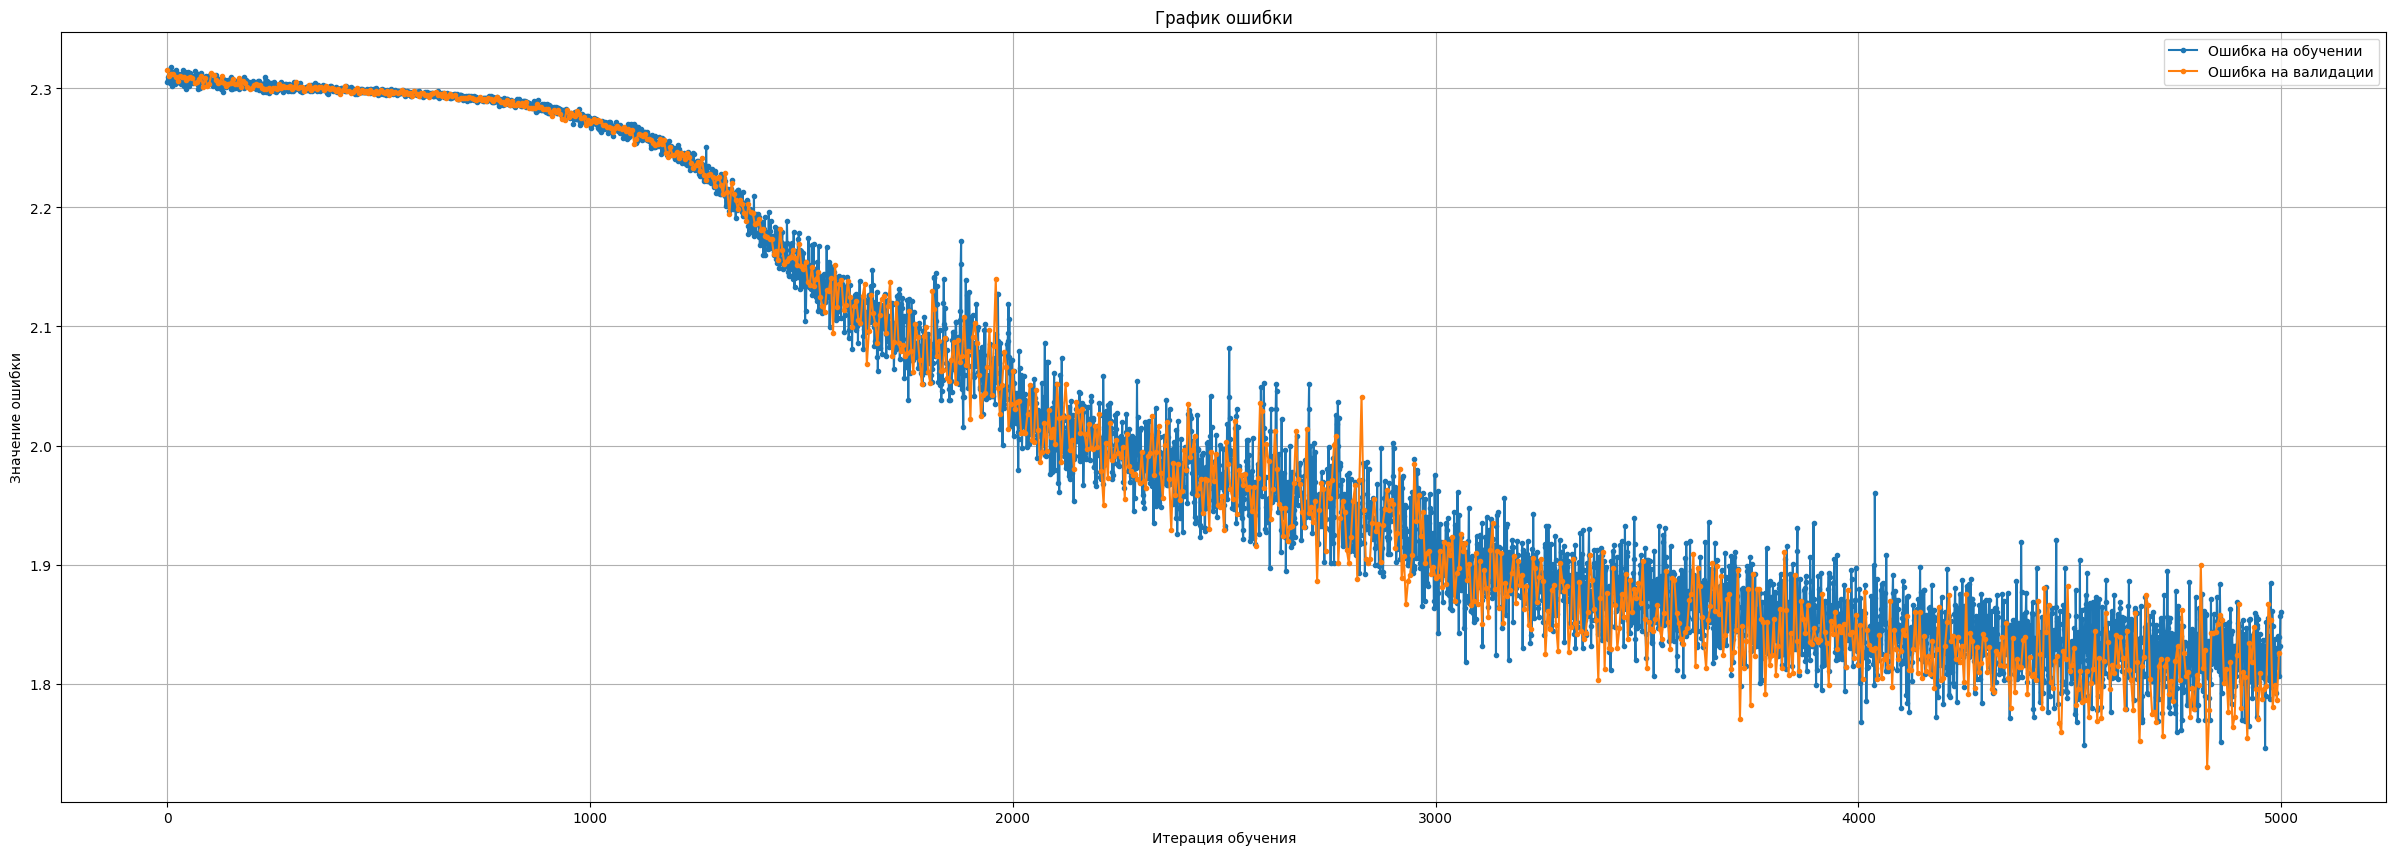

In [28]:
# Реализуем цикл обучения модели.
# ВАЖНО, что обучение модели с параметрами, приведёнными ниже, работает очень долго.

from IPython.display import clear_output

# Для ускорения обучения используем видеокарту компьютера
#  или виртуальной машины, если есть такая возможность.
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

num_epochs = 5000
batch_size = 1000
val_every = 5

model = ResidualModel(
    out_size=10,
    residual_sizes=[(2, 8, 3), (2, 16, 3), (2, 32, 3)],
    linear_sizes=[32],
    activation=torch.nn.ReLU,
    flatten=False,
).to(dtype=x_train.dtype, device=device)  # Важно, чтобы все тензоры были одного типа и на одном устройстве.

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-2,
)

# Шедулер (scheduler) отвечает за изменение величины шага градиентного спуска, который
#  в данном случае мы будем постепенно уменьшать с течением времени.
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.5)

loss_fn = torch.nn.NLLLoss()

losses = {"train": [], "val": []}

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()

    # Будем на каждой итерации обучения брать не все 50 000 картинок,
    #  а лишь случайные batch_size из них.
    batch_pos = torch.randint(high=x_train.shape[0], size=[batch_size])

    pred = model(x_train[batch_pos].to(device))  # Также переносим тензоры на устойство.
    loss = loss_fn(pred, y_train[batch_pos].to(device))

    loss.backward()
    optimizer.step()

    losses["train"].append(loss.item())

    # Каждые val_every итераций считаем значение loss на валидационной выборке.
    if epoch % val_every == 0:
        with torch.no_grad():
            val_batch_pos = torch.randint(high=x_val.shape[0], size=[batch_size])
            val_pred = model(x_val[val_batch_pos].to(device))
            val_loss = loss_fn(val_pred, y_val[val_batch_pos].to(device))
            losses["val"].append(val_loss.item())

    # Каждые 1000 итераций уменьшаем шаг градиентного спуска.
    if epoch % 1000 == 0:
        scheduler.step()

    # Каждые 100 итераций рисуем графики loss.
    if epoch % 100 == 0:
        clear_output(True)
        fig, ax = plt.subplots(figsize=(30, 10))
        plt.title("График ошибки")
        plt.plot(losses["train"], ".-", label="Ошибка на обучении")
        plt.plot(torch.arange(0, epoch, val_every), losses["val"], ".-", label="Ошибка на валидации")
        plt.xlabel("Итерация обучения")
        plt.ylabel("Значение ошибки")
        plt.legend()
        plt.grid()
        plt.show()

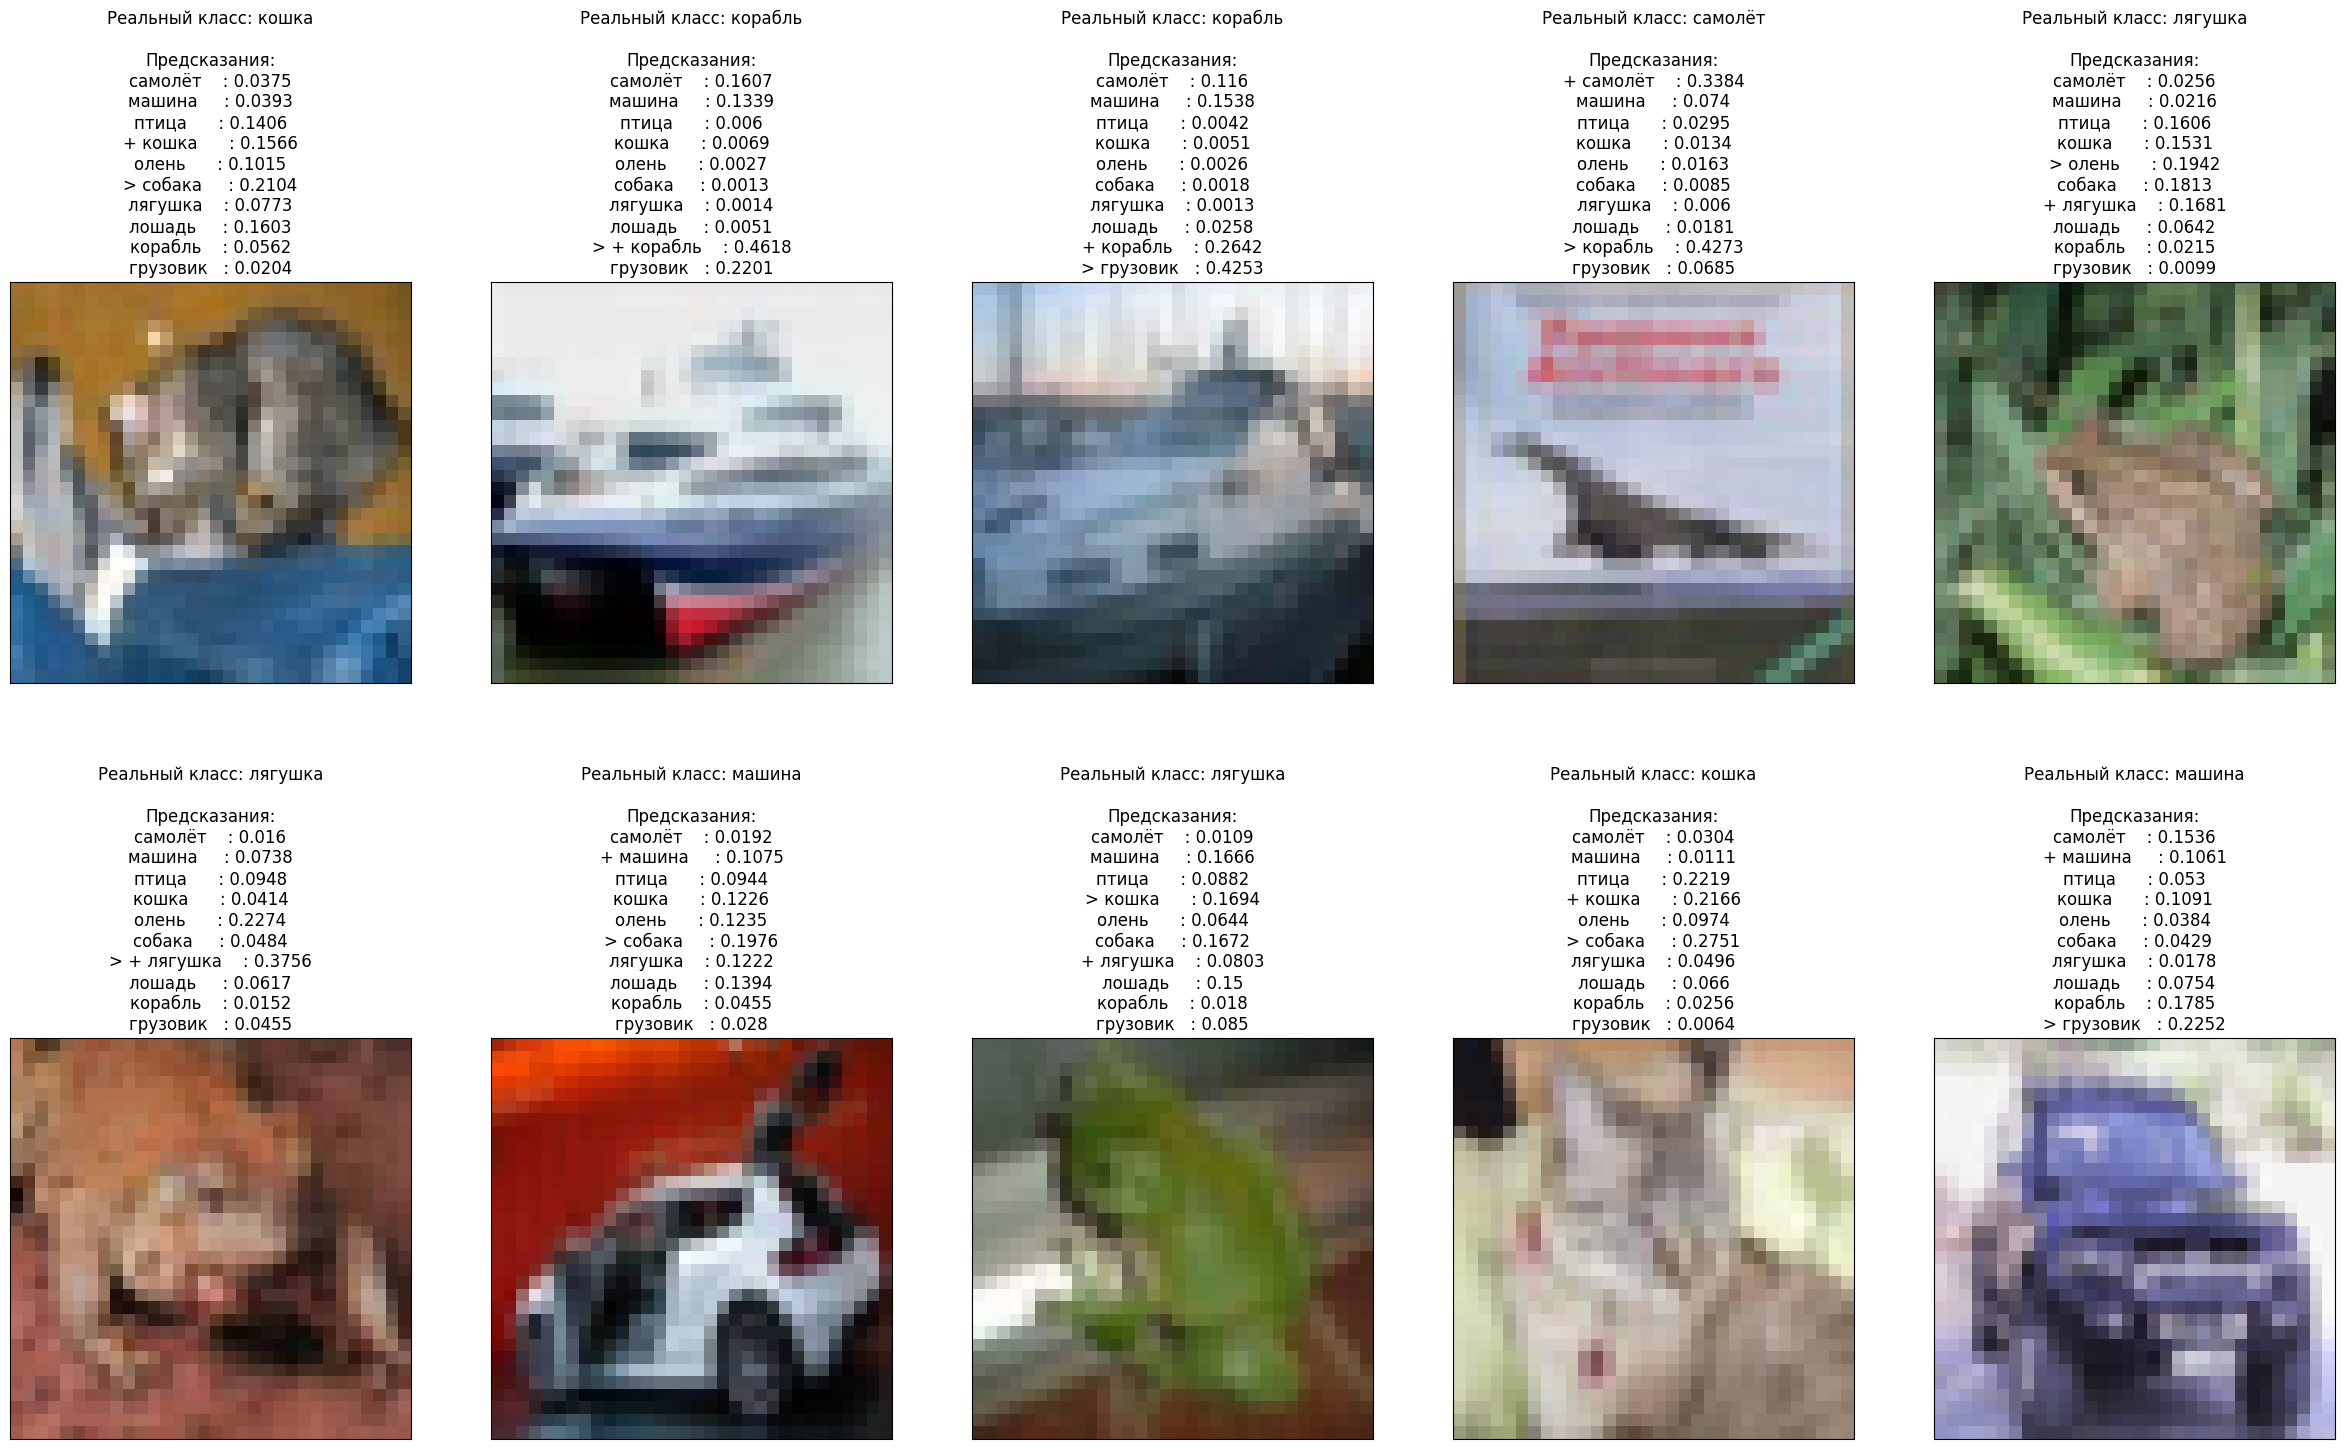

In [29]:
# Посмотрим на предсказания нашей модели на примерах из валидационной выборки.

classes_ru = [
    "самолёт",
    "машина",
    "птица",
    "кошка",
    "олень",
    "собака",
    "лягушка",
    "лошадь",
    "корабль",
    "грузовик",
]

def show_results(model, h=2, w=5):
    with torch.no_grad():
        batch_probs = model(x_val[:h*w].to(device)).exp()

        fig, ax = plt.subplots(h, w, figsize=(30, 9 * h))
        for i in range(h * w):
            plt.subplot(h, w, i+1)
            plt.imshow(x_val[i])
            title = f'Реальный класс: {classes_ru[y_val[i]]}\n\nПредсказания:'
            y_pred = torch.argmax(batch_probs[i])
            for j, prob in enumerate(batch_probs[i]):
                title += '\n{}{}{: <10} : {}'.format(
                    "" if j != y_pred else "> ",
                    "" if j != y_val[i] else "+ ",
                    classes_ru[j],
                    round(prob.item(), 4),
                )

            plt.title(title)
            plt.xticks([])
            plt.yticks([])
        plt.show()

show_results(model)

#### Задание.
Примените технологию residual connection для нейросети из задания № 2. 

1) Опишите архитектуру нейросети

2) Создайте экземпляр класса ResidualModel

3) Проведите обучение нейронной сети. Сделайте отображение величины ошибки для тренировочной и валидационной выборки нак графике в процесе вычислений (аналогично примеру выше). 

4) Отобразите результат классификации с указанием класса-результата и верного ответа для 10 случайных картинок тестовой выборки (аналогично примеру выше).
5) Сравните точность полученной модели с той, что была реализована в задании № 2.
   

In [1]:
import torchvision.datasets
Caltech101_dt = torchvision.datasets.Caltech101('C:/Users/leous/.vscode/computer_vision/practice_2/.Hide', download=True)


KeyboardInterrupt: 

В данном случае Dense блоки были заменены на Residual с последующими правками

In [ ]:
from torchvision import transforms
from torch.utils.data import Subset, DataLoader

# Определяем преобразование данных
transform = transforms.Compose([
    transforms.Lambda(lambda x: x[0] if isinstance(x, tuple) else x),  # Извлекаем изображение из кортежа
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.expand(3, -1, -1) if x.size(0) == 1 else x),  # Преобразование одноканальных изображений в трёхканальные
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# Применяем преобразование к исходному датасету
Caltech101_dt.transform = transform

# Определяем количество данных
num_samples = len(Caltech101_dt)

# Перемешиваем индексы всего датасета
indices = torch.randperm(num_samples)

# Определяем индексы для train, test и validation
train_size = int(0.7 * num_samples)  # 70% для train
test_size = int(0.2 * num_samples)   # 20% для test
val_size = num_samples - train_size - test_size  # 10% для validation

# Разделяем индексы на train, test и validation
train_indices = indices[:train_size]
test_indices = indices[train_size:train_size + test_size]
val_indices = indices[train_size + test_size:]

# Создаем подмножества данных
train_dataset = Subset(Caltech101_dt, train_indices)
test_dataset = Subset(Caltech101_dt, test_indices)
val_dataset = Subset(Caltech101_dt, val_indices)

# Применяем преобразование к каждому набору данных
train_dataset.transform = transform
test_dataset.transform = transform
val_dataset.transform = transform

# Создаем загрузчики данных
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
# ваш код здесь
import torch.nn as nn
import torch.nn.functional as F

class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)
        self.activation = nn.SiLU()

    def forward(self, x):
        out = self.conv(self.activation(self.bn(x)))
        out = torch.cat([x, out], dim=1)  # Concatenate along the channel dimension
        return out

class DenseBlock(nn.Module):
    def __init__(self, in_channels, num_layers, growth_rate):
        super(DenseBlock, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            # Каждый ResidualBlock принимает текущее количество каналов и выдает growth_rate каналов
            layer = ResidualBlock(
                input_c=in_channels + i * growth_rate,
                output_c=growth_rate,
                kernel_size=3
            )
            self.layers.append(layer)

    def forward(self, x):
        features = [x]
        for layer in self.layers:
            new_features = layer(torch.cat(features, dim=1))
            features.append(new_features)
        return torch.cat(features, dim=1)

class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.activation = nn.SiLU()

    def forward(self, x):
        out = self.conv(self.activation(self.bn(x)))
        out = self.pool(out)
        return out

class DenseNet121(nn.Module):
    def __init__(self, num_classes=101, growth_rate=16, block_config=(3, 6, 12, 8)):
        super(DenseNet121, self).__init__()
        self.num_classes = num_classes
        self.growth_rate = growth_rate

        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.activation = nn.SiLU()
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Dense blocks
        in_channels = 64
        self.dense_blocks = nn.ModuleList()
        self.transition_layers = nn.ModuleList()
        
        for i, num_layers in enumerate(block_config):
            self.dense_blocks.append(DenseBlock(in_channels, num_layers, growth_rate))
            in_channels += num_layers * growth_rate
            if i != len(block_config) - 1:
                out_channels = in_channels // 2
                self.transition_layers.append(TransitionLayer(in_channels, out_channels))
                in_channels = out_channels

        # Final batch norm
        self.bn_final = nn.BatchNorm2d(in_channels)

        # Classifier
        self.fc = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        # Initial convolution
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.pool1(x)

        # Dense blocks and transition layers
        for i in range(len(self.dense_blocks)):
            x = self.dense_blocks[i](x)
            if i != len(self.dense_blocks) - 1:
                x = self.transition_layers[i](x)

        # Final batch norm and global average pooling
        x = self.bn_final(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)

        # Classifier
        x = self.fc(x)
        return x


# Создаем модель
model = DenseNet121(num_classes=101, growth_rate=16, block_config=(3, 6, 12, 8))
print_num_params(model)

conv1.weight                                   ~ [64, 3, 7, 7]  ~ 9408
bn1.weight                                     ~ [64]           ~ 64
bn1.bias                                       ~ [64]           ~ 64
dense_blocks.0.layers.0.conv.weight            ~ [16, 64, 3, 3] ~ 9216
dense_blocks.0.layers.0.conv.bias              ~ [16]           ~ 16
dense_blocks.0.layers.0.correct_channels.weight ~ [16, 64, 1, 1] ~ 1024
dense_blocks.0.layers.0.correct_channels.bias  ~ [16]           ~ 16
dense_blocks.0.layers.1.conv.weight            ~ [16, 80, 3, 3] ~ 11520
dense_blocks.0.layers.1.conv.bias              ~ [16]           ~ 16
dense_blocks.0.layers.1.correct_channels.weight ~ [16, 80, 1, 1] ~ 1280
dense_blocks.0.layers.1.correct_channels.bias  ~ [16]           ~ 16
dense_blocks.0.layers.2.conv.weight            ~ [16, 96, 3, 3] ~ 13824
dense_blocks.0.layers.2.conv.bias              ~ [16]           ~ 16
dense_blocks.0.layers.2.correct_channels.weight ~ [16, 96, 1, 1] ~ 1536
dense_blocks.0.

In [ ]:
from torchinfo import summary
summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
DenseNet121                              [32, 101]                 --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─SiLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─ModuleList: 1-11                       --                        (recursive)
│    └─DenseBlock: 2-1                   [32, 112, 56, 56]         --
│    │    └─ModuleList: 3-1              --                        38,496
├─ModuleList: 1-10                       --                        (recursive)
│    └─TransitionLayer: 2-2              [32, 56, 28, 28]          --
│    │    └─BatchNorm2d: 3-2             [32, 112, 56, 56]         224
│    │    └─SiLU: 3-3                    [32, 112, 56, 56]         --
│    │    └─Conv2d: 3-4                  [32, 56, 56, 56] 

In [ ]:
import csv
import os
import gc
from tqdm import tqdm  # Импортируем tqdm
def save_statistics_to_csv(statistics, filename="training_statistics.csv"):
    # Сохраняем статистику в CSV файл
    headers = ["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"]
    
    with open(filename, mode="w", newline='') as file:
        writer = csv.writer(file)
        writer.writerow(headers)
        for row in statistics:
            writer.writerow(row)

In [ ]:

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()  # Функция потерь для классификации
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)  # Оптимизатор Adam

gc.collect()

torch.cuda.empty_cache()

def save_checkpoint(model, optimizer, epoch, checkpoint_path, loss=None):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, checkpoint_path + str(epoch) + ".pt")

def load_checkpoint(model, optimizer, checkpoint_path):
    latest_checkpoint = None
    for i in range(100):  # Предположим, что у нас не более 100 чекпоинтов
        checkpoint_file = checkpoint_path + str(i) + ".pt"
        if os.path.exists(checkpoint_file):
            latest_checkpoint = checkpoint_file
        else:
            break
    
    if latest_checkpoint:
        print(f"Загружаем сохраненный чекпоинт из {latest_checkpoint}...")
        checkpoint = torch.load(latest_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        loss = checkpoint['loss']
        print(f"Продолжаем обучение с эпохи {start_epoch}")
        return start_epoch, loss
    else:
        print("Чекпоинт не найден, начинаем обучение с нуля.")
        return 0, None

def evaluate(model, val_loader, criterion, device):
    model.eval()  # Переводим модель в режим оценки
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Выключаем градиенты для оценки
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # Прямой проход
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Подсчитываем точность
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_val_loss, accuracy

def train(model, train_loader, val_loader, criterion, optimizer, device="cuda", epochs=10, checkpoint_path="checkpoint"):
    model.to(device)  # Перемещаем модель на нужное устройство

    # Загружаем последний чекпоинт, если он существует
    start_epoch, prev_loss = load_checkpoint(model, optimizer, checkpoint_path)

    # Списки для хранения статистики
    statistics = []

    for epoch in range(start_epoch, epochs):
        model.train()  # Переводим модель в режим обучения
        running_loss = 0.0
        correct = 0
        total = 0

        # Используем tqdm для отображения прогресса
        train_loader_tqdm = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False)
        
        for i, data in enumerate(train_loader_tqdm, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Прямой проход
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Обратное распространение и обновление параметров
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Оценка на валидации
            val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

            # Обновляем прогресс-бар
            train_loader_tqdm.set_postfix(
                loss=running_loss / (i + 1),
                accuracy=100 * correct / total,
                val_loss=val_loss,
                val_accuracy=val_accuracy
            )

            # Статистика по обучению
            train_loss = running_loss / len(train_loader)
            train_accuracy = 100 * correct / total

            # Добавляем статистику в список
            statistics.append([epoch + 1, train_loss, train_accuracy, val_loss, val_accuracy])
        
            # После завершения обучения сохраняем статистику в файл
            save_statistics_to_csv(statistics)
        
        print(f'Epoch: {epoch + 1}, Loss: {train_loss}, Accuracy: {train_accuracy}%')
        # Сохраняем чекпоинт
        save_checkpoint(model, optimizer, epoch, checkpoint_path, loss=train_loss)




In [ ]:
train(model, train_loader, test_loader, criterion, optimizer, device="cuda" if torch.cuda.is_available() else "cpu", epochs=6, checkpoint_path="checkpoint")


Чекпоинт не найден, начинаем обучение с нуля.


Epoch: 1, Loss: 4.083415349219974, Accuracy: 13.485921290959986%


Epoch: 2, Loss: 3.293958579239092, Accuracy: 27.416433393709863%


Epoch: 3, Loss: 2.6424244328156896, Accuracy: 38.44887205664416%


Epoch: 4, Loss: 2.2084662954273977, Accuracy: 46.731434217026184%


Epoch: 5, Loss: 1.8519864033515516, Accuracy: 53.59789231022559%


Epoch: 6, Loss: 1.5963345833211668, Accuracy: 59.21290959986827%


Epoch: 1, Loss: 4.083415349219974, Accuracy: 13.485921290959986%

Epoch: 2, Loss: 3.293958579239092, Accuracy: 27.416433393709863%
              
Epoch: 3, Loss: 2.6424244328156896, Accuracy: 38.44887205664416%
              
Epoch: 4, Loss: 2.2084662954273977, Accuracy: 46.731434217026184%
              
Epoch: 5, Loss: 1.8519864033515516, Accuracy: 53.59789231022559%
              
Epoch: 6, Loss: 1.5963345833211668, Accuracy: 59.21290959986827%

In [ ]:

checkpoint_path="checkpoint"
epochs = 5
for i in range(epochs):
    if os.path.exists(checkpoint_path + str(i) + ".pt"):
        s = checkpoint_path + str(i) + ".pt"
if os.path.exists(s):
    print("Загружаем сохраненный чекпоинт...")
    checkpoint = torch.load(s, weights_only=False)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    criterion = checkpoint['loss']

Загружаем сохраненный чекпоинт...


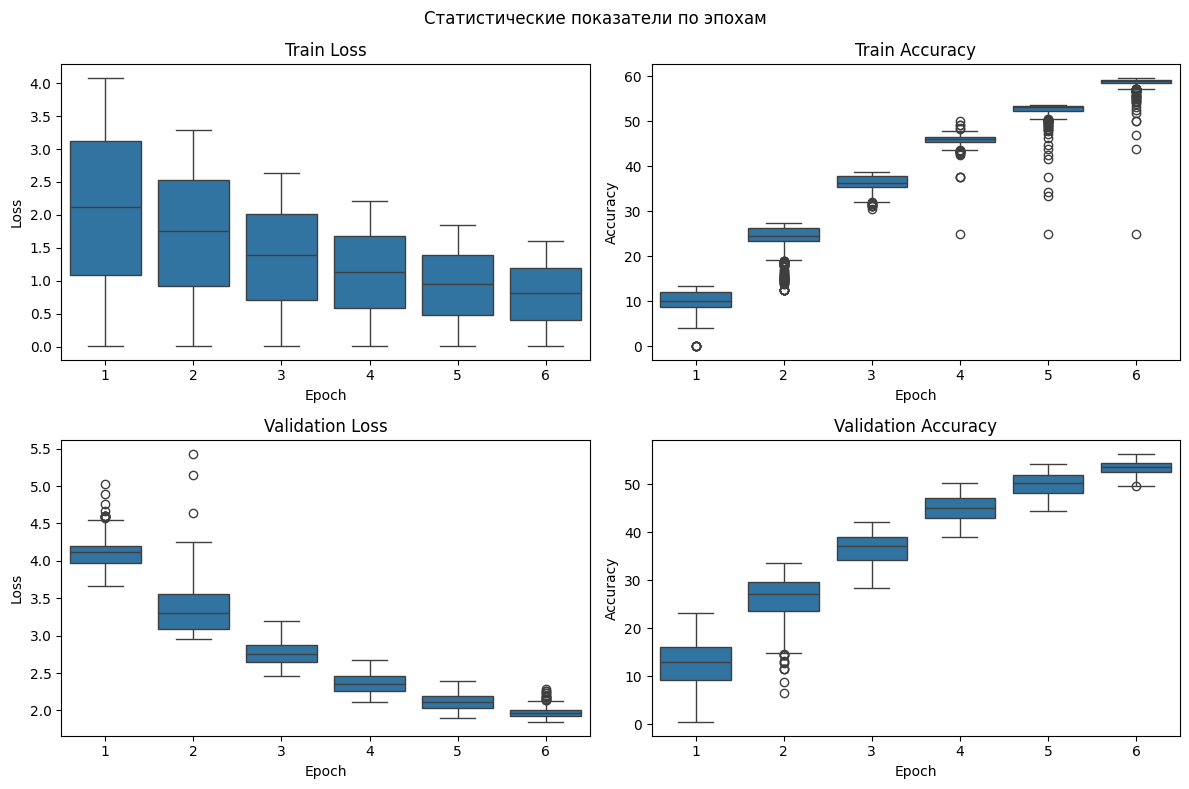

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных из CSV файла
data = pd.read_csv('training_statistics.csv')

# Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Статистические показатели по эпохам')

# График для train_loss
sns.boxplot(x='epoch', y='train_loss', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Train Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')

# График для train_accuracy
sns.boxplot(x='epoch', y='train_accuracy', data=data, ax=axes[0, 1])
axes[0, 1].set_title('Train Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')

# График для val_loss
sns.boxplot(x='epoch', y='val_loss', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Validation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')

# График для val_accuracy
sns.boxplot(x='epoch', y='val_accuracy', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')

# Отображение графиков
plt.tight_layout()
plt.show()

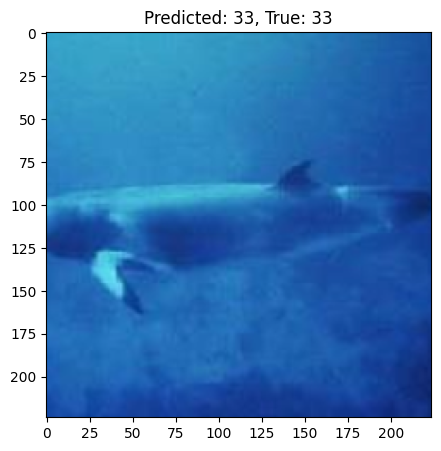

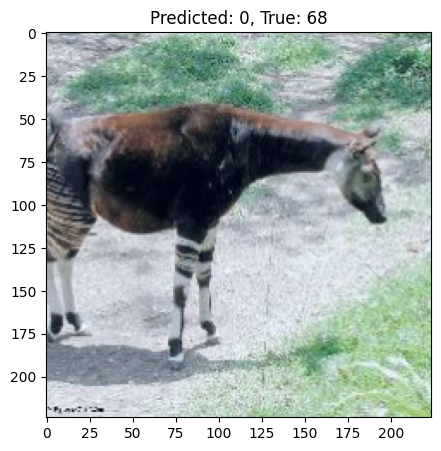

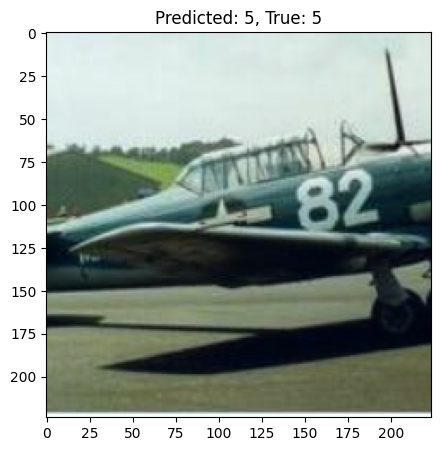

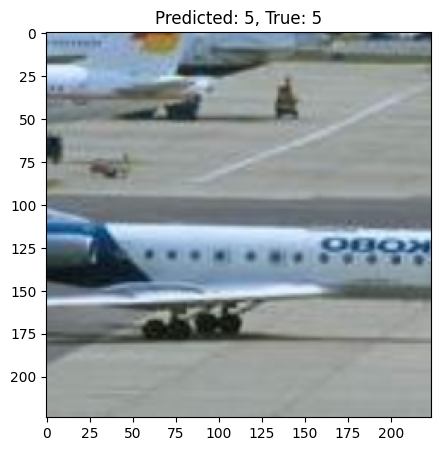

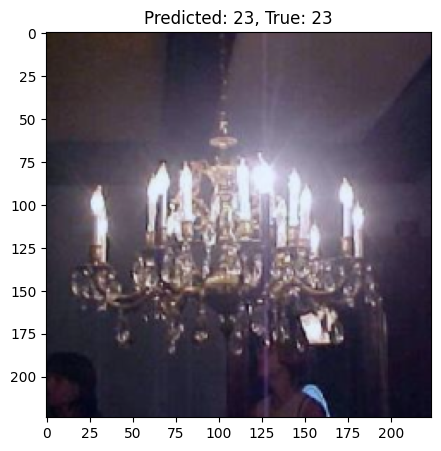

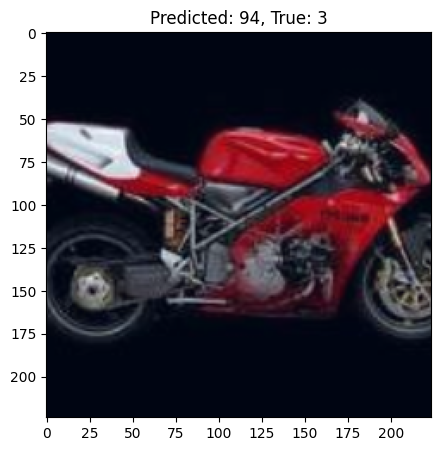

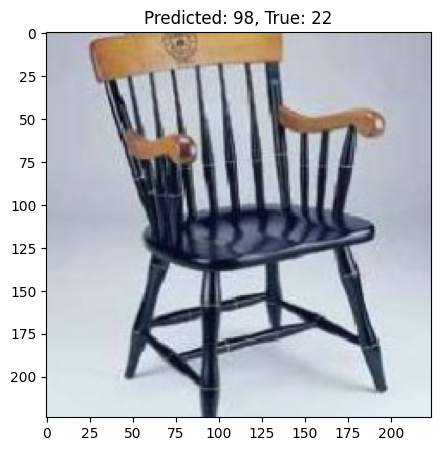

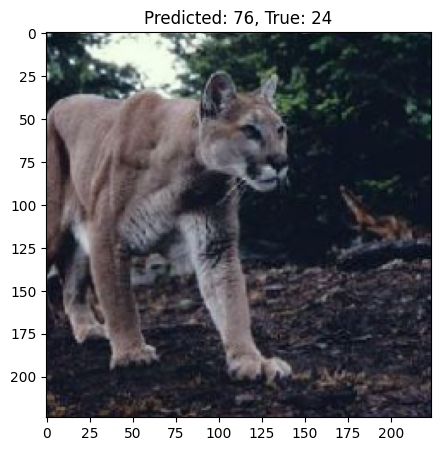

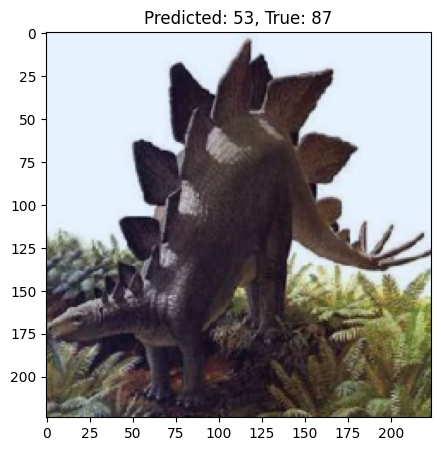

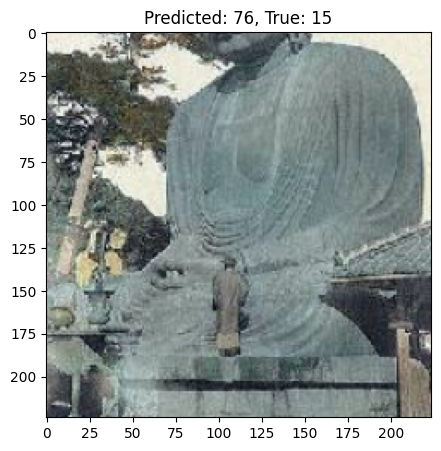

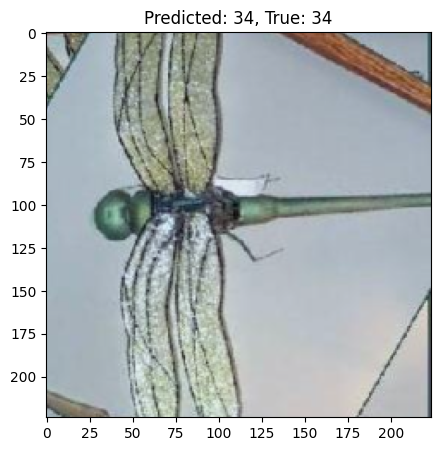

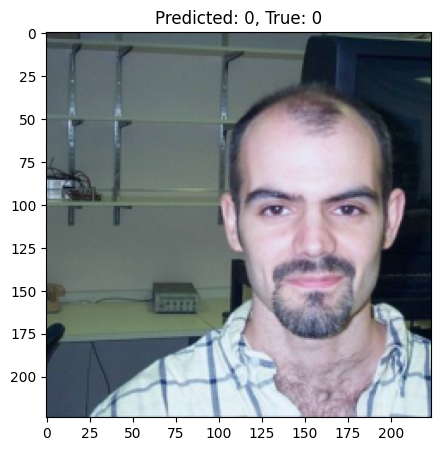

In [ ]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

def show_images_and_labels(val_loader, model, device="cuda" if torch.cuda.is_available() else "cpu", num_images=5):
    model.eval()  # Устанавливаем модель в режим оценки
    model.to(device)  # Перемещаем модель на выбранное устройство

    with torch.no_grad():  # Отключаем вычисление градиентов для ускорения
        for i, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            # print(outputs.data)
            _, predicted = torch.max(outputs.data, 1)
            # Выводим изображение, предсказанный лейбл и настоящий лейбл
            for j in range(min(num_images, images.size(0))):
                plt.figure(figsize=(5, 5))
                plt.imshow(torchvision.utils.make_grid(images[j].cpu(), normalize=True).permute(1, 2, 0))
                plt.title(f'Predicted: {predicted[j].item()}, True: {labels[j].item()}')
                plt.show()

            if i >= num_images:
                break

# Пример использования
# show_images_and_labels(val_loader, model, device="cuda" if torch.cuda.is_available() else "cpu", num_images=5)
show_images_and_labels(val_loader, model, device="cuda" if torch.cuda.is_available() else "cpu", num_images=3)

По итогам обучения составим сравнительную таблицу
```
Эпоха	1 реализация	        2 реализация  
1	13.205993742795982%	13.485921290959986%  
2	22.509468137658487%	27.416433393709863%  
3	30.11691091717438%	38.44887205664416%  
4	38.15247818211757%	46.731434217026184%  
5		                53.59789231022559%  
6		                59.21290959986827%  
```
Как можно заметить, изначально разница не столь велика, но в перспективе достигает 8% на 4 эпохе. Так же отмечу, что скорость обучения значительно выросла